In [2]:
import os
import json
import numpy as np
import pandas as pd
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import re

In [54]:
df = pd.read_csv("multi_pflip.csv")

In [81]:
# ------------------------------------------------------------
# 3)  Build pivot table: rows = qubit, columns = cycle_id
# ------------------------------------------------------------
def gen_heat_map(df):
    heat = (
        df.pivot_table(index="qubit",
                       columns="cycle_order",
                       values="p_flip",
                       aggfunc="mean")          # avg if duplicates
          .sort_index()                         # qubits in numeric order
    )
    
    # ------------------------------------------------------------
    # 4)  Plot heat-map
    # ------------------------------------------------------------
    sns.set_context("notebook", font_scale=1.3) 
    plt.figure(figsize=(16, 16))
    ax = sns.heatmap(
        heat,
        cmap="mako",         # perceptually-uniform dark→light
        vmin=0, vmax=1,      # 0 to 100 % flip rate
        cbar_kws={"label": "p _flip"}
    )
    
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Physical qubit index")
    ax.set_title("Bit-flip probability across the lattice over time")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('plots/heapmap.png')
    plt.show()


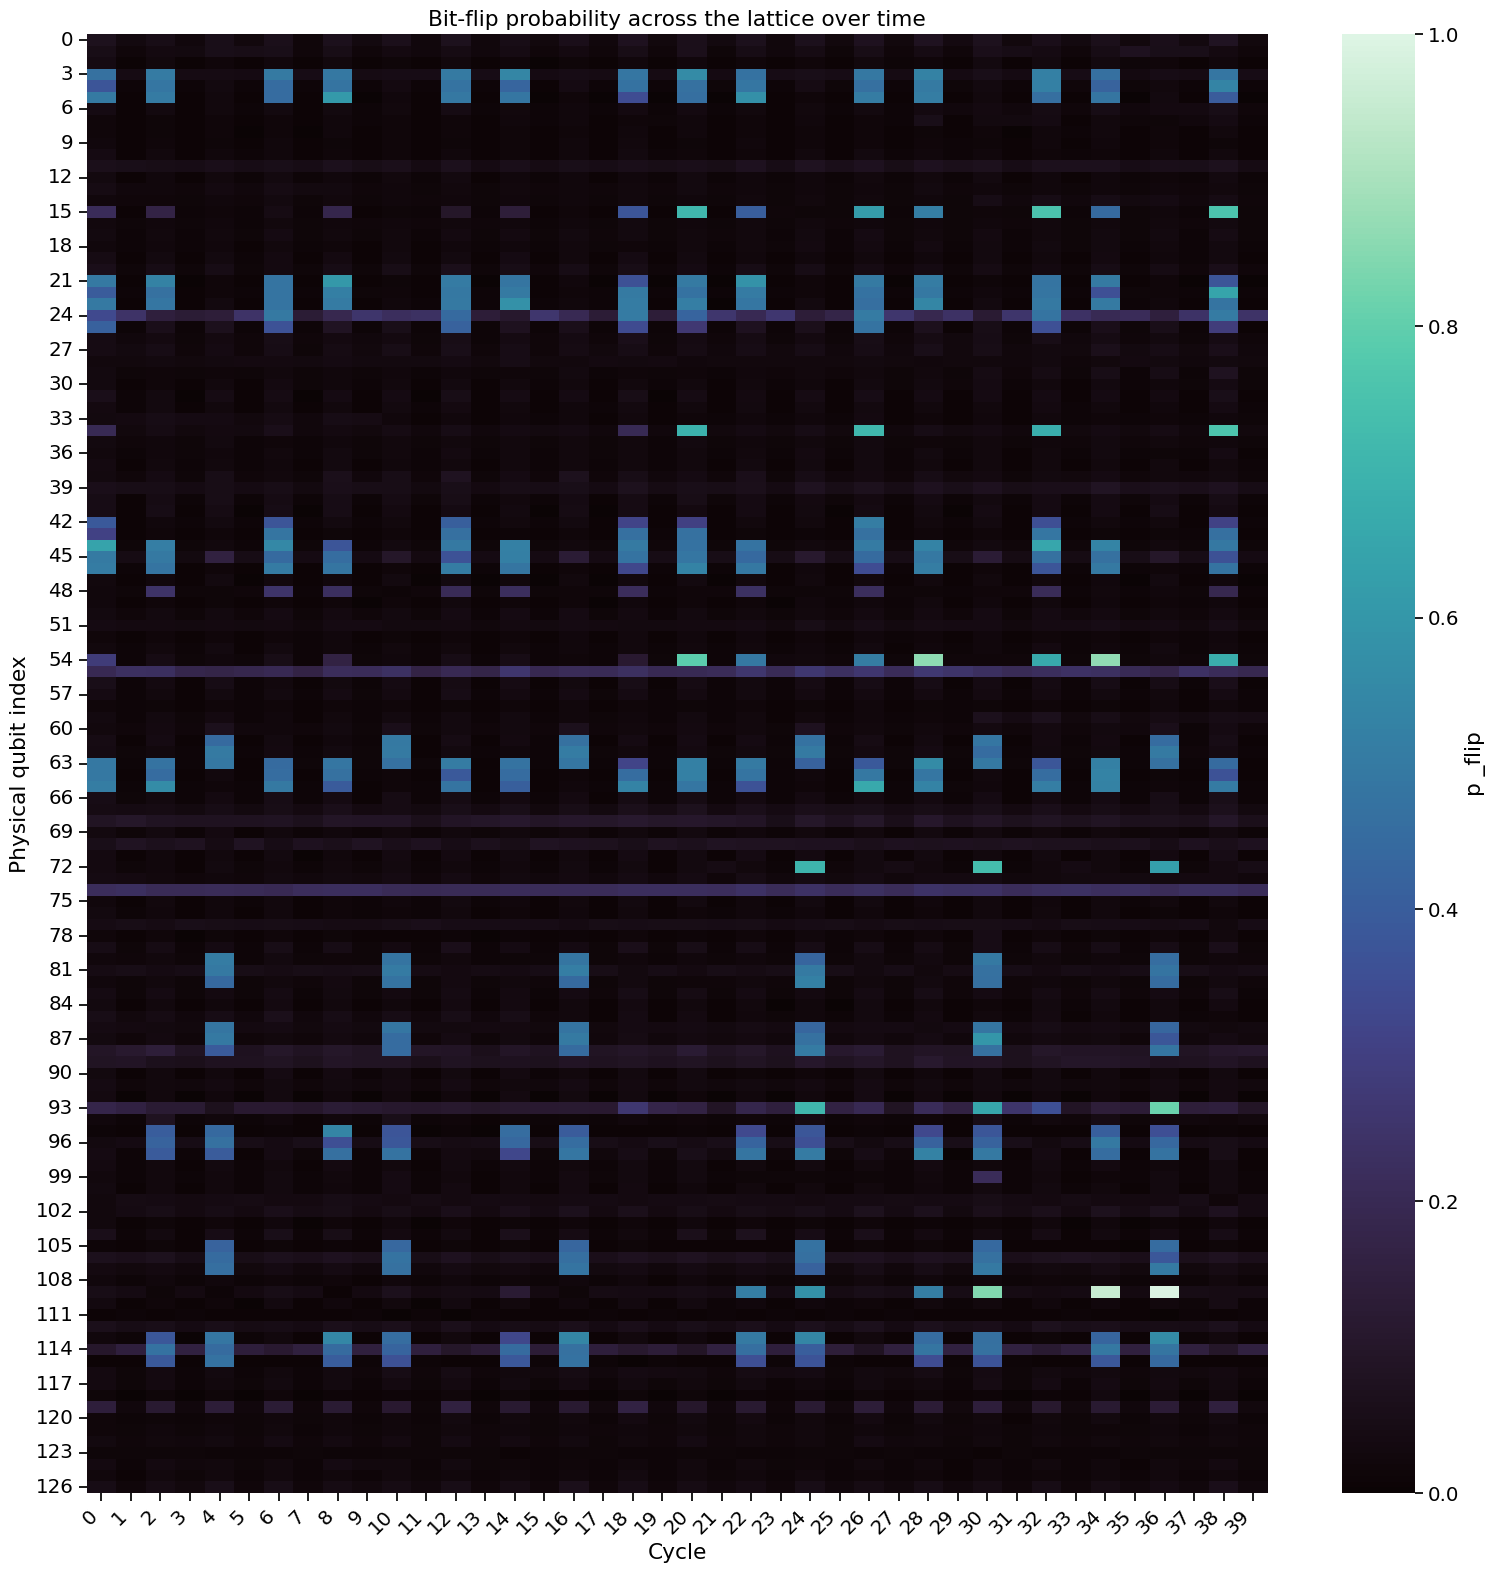

In [83]:
gen_heat_map(df)

In [31]:
df_multi[df_multi['init_state']==1]

,timestamp,cycle,hammer,init_state,center_group,qubit,count_0,count_1
2540,20250513T032034,0,True,1,"[15, 34, 54]",0,3755,245
2541,20250513T032034,0,True,1,"[15, 34, 54]",1,3752,248
2542,20250513T032034,0,True,1,"[15, 34, 54]",2,3909,91
2543,20250513T032034,0,True,1,"[15, 34, 54]",3,1780,2220
2544,20250513T032034,0,True,1,"[15, 34, 54]",4,2139,1861
...,...,...,...,...,...,...,...,...
5075,20250513T033709,19,False,1,"[72, 93, 109]",122,3928,72
5076,20250513T033709,19,False,1,"[72, 93, 109]",123,3939,61
5077,20250513T033709,19,False,1,"[72, 93, 109]",124,3948,52
5078,20250513T033709,19,False,1,"[72, 93, 109]",125,3957,43


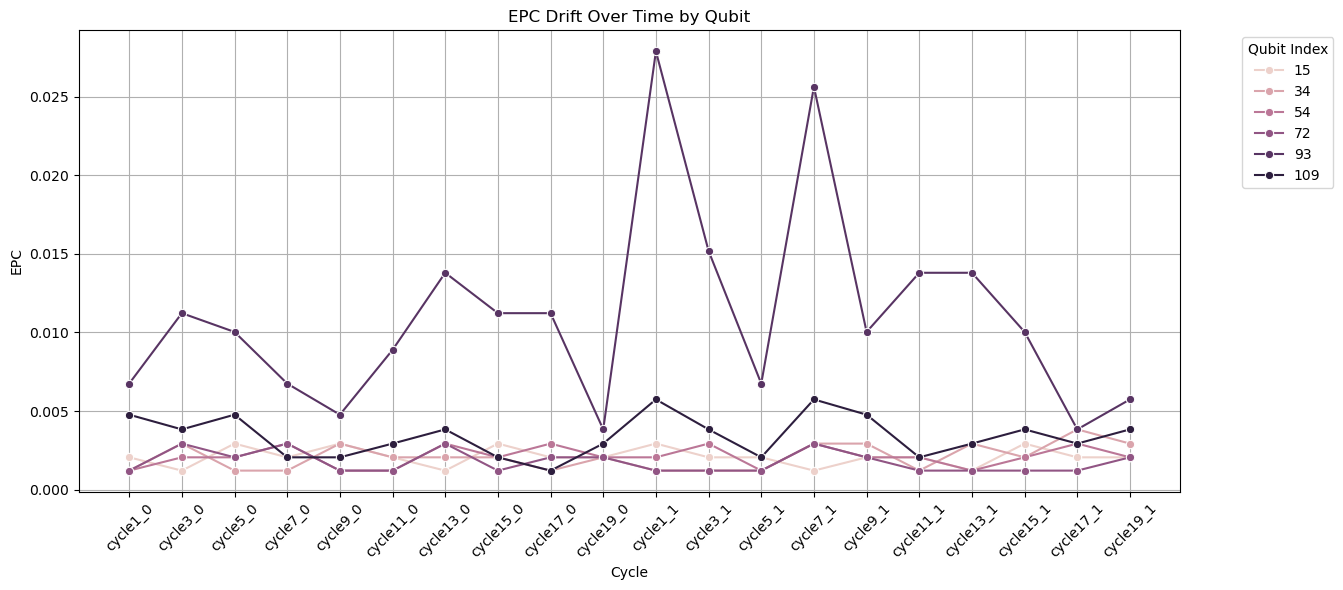

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load the consolidated EPC CSV
df = pd.read_csv("epc_consolidated.csv")

# Parse (cycle_number, suffix_index) from string like "cycle7_1"
def parse_cycle_id_order(cid):
    match = re.match(r"cycle(\d+)_([01])", cid)
    if match:
        cycle_num = int(match.group(1))
        suffix = int(match.group(2))
        return (suffix, cycle_num)  # ← This gives: _0 group first, then _1
    return (99, 99)  # fallback: sort unknowns to the end

df["cycle_order"] = df["cycle_id"].apply(parse_cycle_id_order)
df = df.sort_values("cycle_order")

# Assign a clean x-axis index for plotting
unique_cycles = df["cycle_id"].unique()
cycle_map = {cycle: i for i, cycle in enumerate(unique_cycles)}
df["cycle_num"] = df["cycle_id"].map(cycle_map)

# Plot EPC over time for each q_ind
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="cycle_num", y="epc", hue="q_ind", marker="o")

# Set clean x-axis labels
plt.xticks(ticks=range(len(unique_cycles)), labels=unique_cycles, rotation=45)
plt.xlabel("Cycle")
plt.ylabel("EPC")
plt.title("EPC Drift Over Time by Qubit")
plt.tight_layout()
plt.grid(True)
plt.legend(title="Qubit Index", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()
